In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
from pandas.api.types import CategoricalDtype
import itertools
from colour import Color
from datetime import date
import tifffile
import scipy  as spy
import skimage as ski

In [2]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-01-26_DCX-HUGS-WT_freshtaxol/CH1_1nM-DCXHUGSWT40P')

In [3]:
composite=path/'2_Composite-driftcorrected.tif'
composite

WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-01-26_DCX-HUGS-WT_freshtaxol/CH1_1nM-DCXHUGSWT40P/2_Composite-driftcorrected.tif')

In [4]:
im_dcx,im_mts = tifffile.imread(composite)

In [8]:
otsu_marker = ski.filters.threshold_otsu(im_mts)
im_mts_otsu = im_mts > otsu_marker

label_objects, nb_labels = spy.ndimage.label(im_mts_otsu)
sizes = np.bincount(label_objects.ravel())
mask_sizes = sizes > 20
mask_sizes[0] = 0

im_mts_cleaned = mask_sizes[label_objects]

im_mts_cleaned = im_mts_cleaned.astype(np.uint16)

In [9]:
im_dcx_masked = im_dcx * im_mts_cleaned

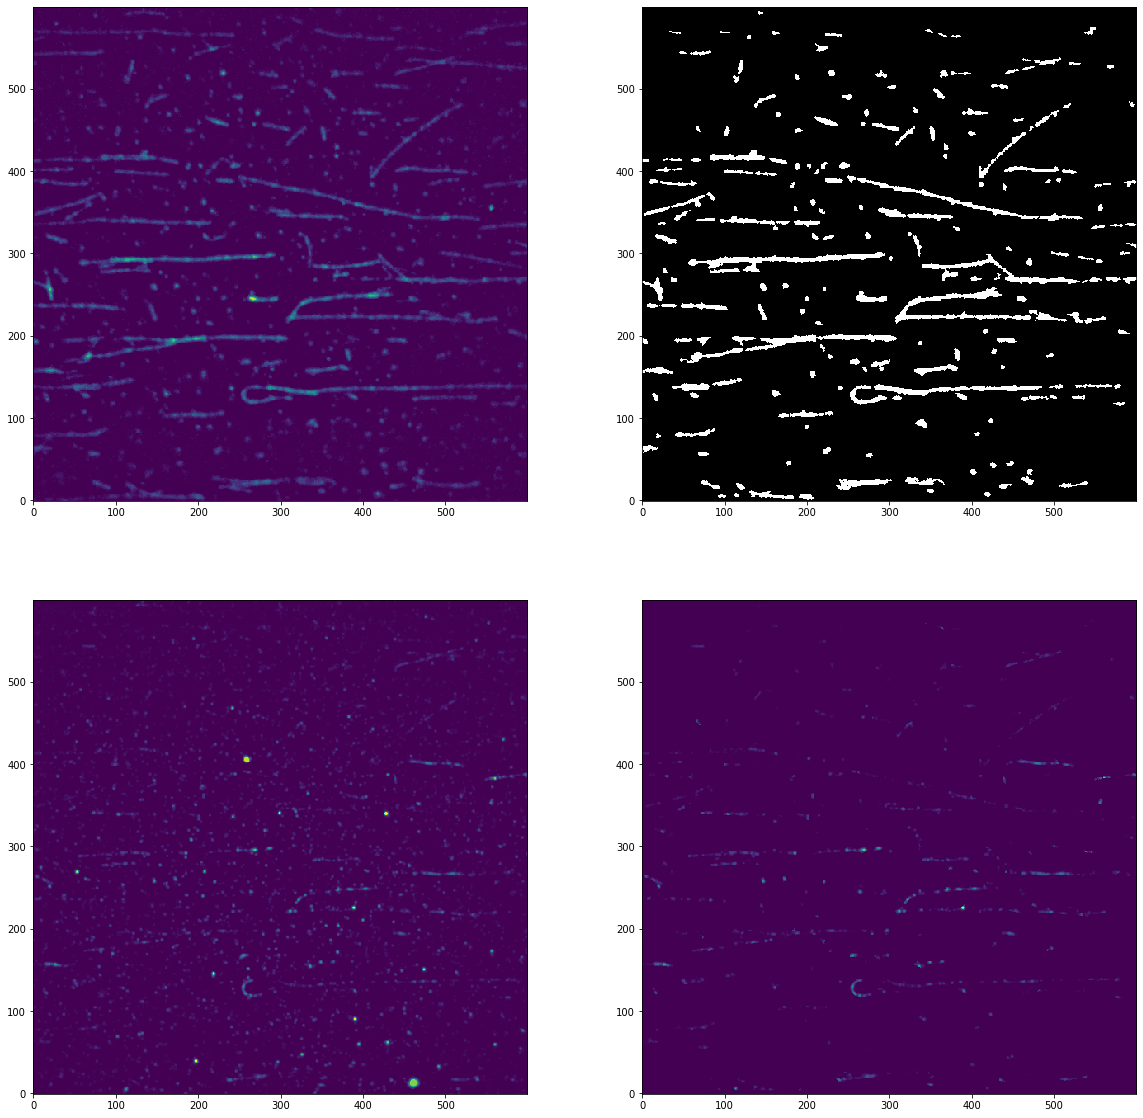

In [10]:
fig, ax = plt.subplots(2,2,figsize=(20, 20))

ax[0,0].imshow(im_mts, interpolation='none', origin=[0, 0], cmap='viridis')
ax[0,1].imshow(im_mts_cleaned, interpolation='none', origin=[0, 0], cmap='gray')
ax[1,0].imshow(im_dcx, interpolation='none', origin=[0, 0], cmap='viridis')
ax[1,1].imshow(im_dcx_masked, interpolation='none', origin=[0, 0], cmap='viridis')

In [11]:
im_cleaned = np.append([im_dcx_masked], [im_mts_cleaned],axis=0)
tifffile.imsave(path/'test.tif', im_cleaned)

In [14]:
coeff, pval = spy.stats.pearsonr(im_mts_cleaned.flatten(), im_dcx_masked.flatten())
coeff, pval

(0.48384799516348004, 0.0)

In [23]:
otsu_marker_dcx = ski.filters.threshold_otsu(im_dcx_masked)
im_dcx_otsu = im_dcx_masked > otsu_marker_dcx
im_dcx_otsu = im_dcx_otsu.astype(np.uint16)*10

In [24]:
coeff, pval = spy.stats.pearsonr(im_mts_cleaned.flatten(), im_dcx_otsu.flatten())
coeff, pval

(0.37688674000392214, 0.0)

In [25]:
im_otsu = np.append([im_dcx_otsu], [im_mts_cleaned],axis=0)
tifffile.imsave(path/'test2.tif', im_otsu)